
# # 03 - EDA, tests statistiques & clustering

# Entrée: data/processed/dataset_model.csv


In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

DATA_PATH = os.path.join("..","data", "processed", "dataset_model.csv")
df = pd.read_csv(DATA_PATH)

TARGET = "readmitted"
print(df.shape)
print(df[TARGET].value_counts())

C:\Users\HL\AppData\Local\Temp\ipykernel_20656\3449448869.py:12: DtypeWarning: Columns (0: payer_code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_PATH)


(101766, 53)
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


## 1) Univarié — distributions & outliers

In [2]:
num_cols = [c for c in df.columns if df[c].dtype != "object" and c != TARGET]
num_cols[:15]

['encounter_id',
 'patient_nbr',
 'race',
 'gender',
 'age',
 'weight',
 'admission_type_id',
 'discharge_disposition_id',
 'admission_source_id',
 'time_in_hospital',
 'payer_code',
 'medical_specialty',
 'num_lab_procedures',
 'num_procedures',
 'num_medications']

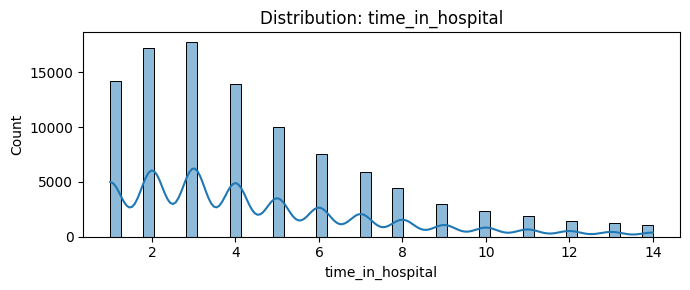

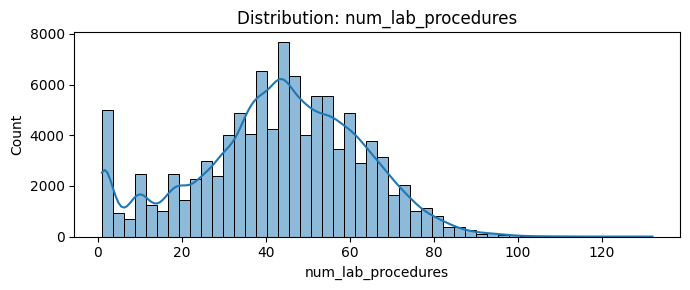

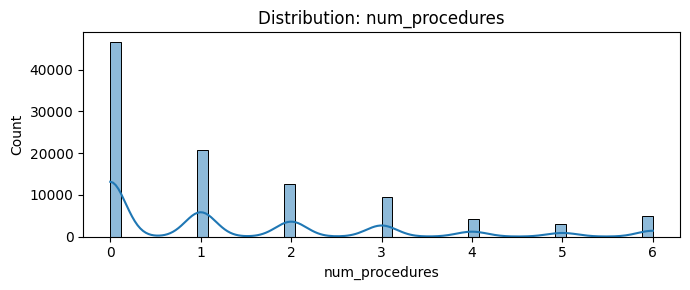

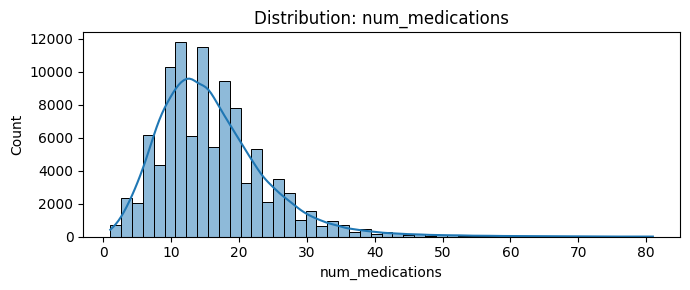

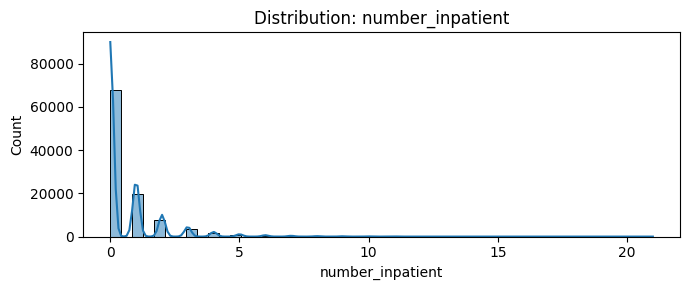

In [3]:
def hist_plot(col):
    plt.figure(figsize=(7, 3))
    sns.histplot(df[col].dropna(), bins=50, kde=True)
    plt.title(f"Distribution: {col}")
    plt.tight_layout()
    plt.show()


for col in ["time_in_hospital", "num_lab_procedures", "num_procedures", "num_medications", "number_inpatient"]:
    if col in df.columns:
        hist_plot(col)

## 2) Bivarié — par classe

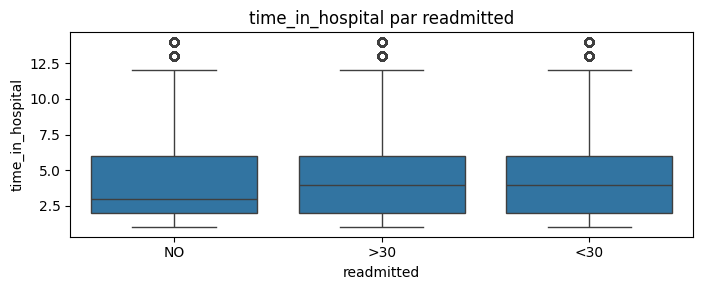

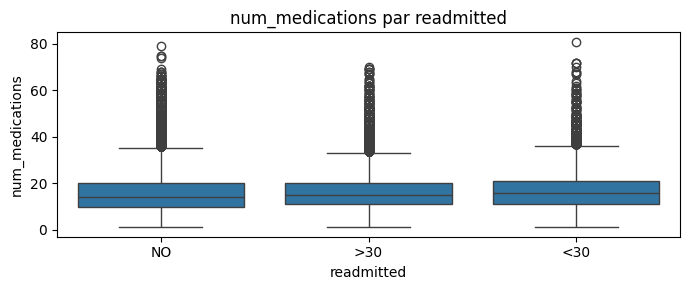

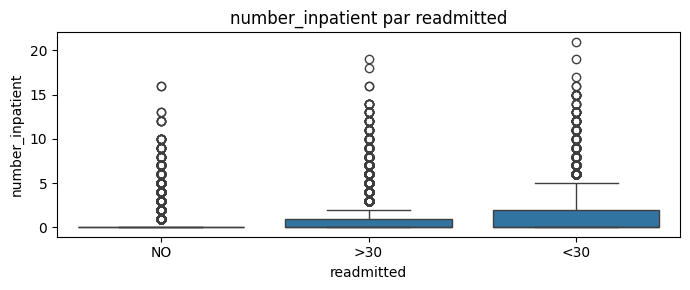

In [4]:
def box_by_target(col):
    plt.figure(figsize=(7, 3))
    sns.boxplot(data=df, x=TARGET, y=col)
    plt.title(f"{col} par {TARGET}")
    plt.tight_layout()
    plt.show()


for col in ["time_in_hospital", "num_medications", "number_inpatient"]:
    if col in df.columns:
        box_by_target(col)

## 3) Corrélations numériques (heatmap)

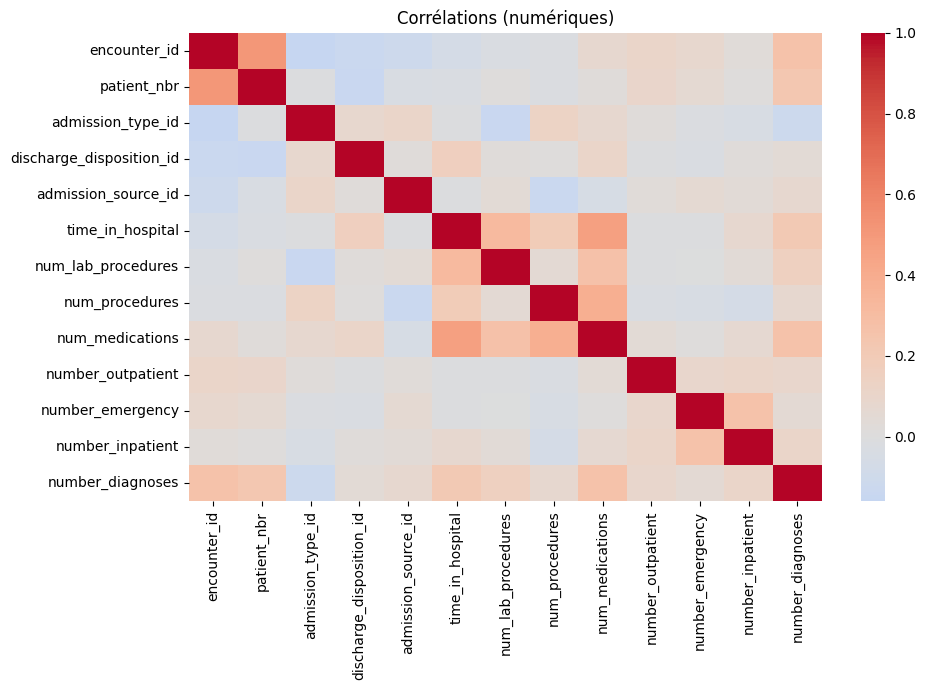

In [5]:
if len(num_cols) >= 3:
    corr = df[num_cols].corr(numeric_only=True)
    plt.figure(figsize=(10, 7))
    sns.heatmap(corr, cmap="coolwarm", center=0)
    plt.title("Corrélations (numériques)")
    plt.tight_layout()
    plt.show()

## 4) Tests statistiques
en ordre:
 - chi² sur une variable catégorielle
 - Mann-Whitney sur une variable numérique (<30 vs NO)
 - ANOVA sur une variable numérique (3 classes)

In [ ]:
# Chi² sur une variable catégorielle : la variable choisie est celle de faible cardinalité.
cat_cols = [c for c in df.columns if df[c].dtype == "object" and c != TARGET]
cat_cols[:10]

[]

In [ ]:
def chi2_test(col):
    ct = pd.crosstab(df[col].fillna("NA"), df[TARGET])
    chi2, p, dof, exp = stats.chi2_contingency(ct)
    return col, chi2, p, dof, ct.shape


for col in ["gender", "race", "admission_type_id", "discharge_disposition_id"]:
    if col in df.columns:
        print("CHI2:", chi2_test(col))

CHI2: ('gender', np.float64(37.46116999031485), np.float64(1.447272318868805e-07), 4, (3, 3))
CHI2: ('race', np.float64(282.5948012851926), np.float64(7.379468859169466e-55), 10, (6, 3))
CHI2: ('admission_type_id', np.float64(415.76097822524173), np.float64(6.037493259618694e-80), 14, (8, 3))
CHI2: ('discharge_disposition_id', np.float64(3587.291303665676), np.float64(0.0), 50, (26, 3))


In [8]:
def mann_whitney(col):
    a = df[df[TARGET] == "<30"][col].dropna()
    b = df[df[TARGET] == "NO"][col].dropna()
    u, p = stats.mannwhitneyu(a, b, alternative="two-sided")
    return col, u, p, len(a), len(b)


for col in ["time_in_hospital", "num_medications", "number_inpatient"]:
    if col in df.columns:
        print("MW:", mann_whitney(col))

MW: ('time_in_hospital', np.float64(347137030.0), np.float64(1.5215228232551563e-83), 11357, 54864)
MW: ('num_medications', np.float64(345990716.5), np.float64(3.645692996622687e-77), 11357, 54864)
MW: ('number_inpatient', np.float64(401090276.0), np.float64(0.0), 11357, 54864)


In [9]:
def anova_3groups(col):
    g1 = df[df[TARGET] == "<30"][col].dropna()
    g2 = df[df[TARGET] == ">30"][col].dropna()
    g3 = df[df[TARGET] == "NO"][col].dropna()
    f, p = stats.f_oneway(g1, g2, g3)
    return col, f, p, len(g1), len(g2), len(g3)


for col in ["time_in_hospital", "num_lab_procedures", "num_medications"]:
    if col in df.columns:
        print("ANOVA:", anova_3groups(col))

ANOVA: ('time_in_hospital', np.float64(170.33088561750898), np.float64(1.4118153903815785e-74), 11357, 35545, 54864)
ANOVA: ('num_lab_procedures', np.float64(80.21071773284635), np.float64(1.5572432767458205e-35), 11357, 35545, 54864)
ANOVA: ('num_medications', np.float64(136.74921080848242), np.float64(4.900463977640449e-60), 11357, 35545, 54864)


## 5) Clustering exploratoire (KMeans)

In [10]:
features = [c for c in ["time_in_hospital", "num_lab_procedures", "num_procedures",
                        "num_medications", "number_inpatient", "number_emergency", "number_outpatient"] if c in df.columns]
features

['time_in_hospital',
 'num_lab_procedures',
 'num_procedures',
 'num_medications',
 'number_inpatient',
 'number_emergency',
 'number_outpatient']

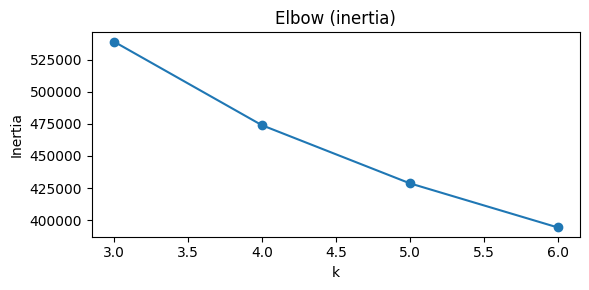

cluster
1    44467
2    29267
0    21184
3     6848
Name: count, dtype: int64


readmitted,<30,>30,NO
cluster,,,
0,0.121412,0.346866,0.531722
1,0.102503,0.348528,0.548969
2,0.087641,0.314040,0.598319
3,0.242699,0.512266,0.245035


,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_inpatient,number_emergency,number_outpatient
cluster,,,,,,,
0,8.071469,55.877266,2.877171,25.542013,0.514964,0.107298,0.226114
1,3.651922,51.111813,0.444240,13.154069,0.431803,0.102863,0.194819
2,2.843681,21.227731,1.696826,13.192264,0.323709,0.101753,0.296853
3,4.491822,44.962909,0.872371,17.286361,3.664574,1.505257,2.255695


In [11]:
if len(features) >= 2:
    X = df[features].fillna(0)
    Xs = StandardScaler().fit_transform(X)

    inertias = []
    ks = [3, 4, 5, 6]
    for k in ks:
        km = KMeans(n_clusters=k, random_state=42, n_init="auto")
        km.fit(Xs)
        inertias.append(km.inertia_)

    plt.figure(figsize=(6, 3))
    plt.plot(ks, inertias, marker="o")
    plt.title("Elbow (inertia)")
    plt.xlabel("k")
    plt.ylabel("Inertia")
    plt.tight_layout()
    plt.show()

    k_final = 4
    km = KMeans(n_clusters=k_final, random_state=42, n_init="auto")
    df["cluster"] = km.fit_predict(Xs)

    print(df["cluster"].value_counts())

    cluster_readm = df.groupby("cluster")[TARGET].value_counts(
        normalize=True).unstack().fillna(0)
    cluster_profile = df.groupby("cluster")[features].mean()

    display(cluster_readm)
    display(cluster_profile)